In [ ]:
import numpy as np  #librería para trabajar con cálculos numéricos y arreglos (matrices, vectores).
import pandas as pd #librería para manejar y analizar datos en tablas (DataFrames).
import seaborn as sns #librería para hacer gráficos estadísticos bonitos y fáciles.
import matplotlib.pyplot as plt #Importa Matplotlib, librería para crear gráficos en Python (básica y muy usada).
%matplotlib inline

survived → indica si la persona sobrevivió (1 = sí, 0 = no).

pclass → clase del pasajero (1ª, 2ª o 3ª).

sex → sexo del pasajero (male = hombre, female = mujer).

age → edad del pasajero.

sibsp → número de hermanos/esposos a bordo.

parch → número de padres/hijos a bordo.

fare → tarifa pagada por el ticket.

embarked → puerto de embarque (C = Cherbourg, Q = Queenstown, S = Southampton).

class → clase en texto (First, Second, Third).

who → tipo de persona (man, woman, child).

adult_male → si es un hombre adulto (True/False).

deck → letra del camarote (muchos faltantes).

embark_town → ciudad de embarque (Cherbourg, Queenstown, Southampton).

alive → indica si sobrevivió en texto (yes/no).

alone → si viajaba solo (True/False).

In [ ]:
df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [ ]:
df.shape

(891, 15)

In [ ]:
df2 = df.sample(n=500 , random_state=42)#El método .sample() de pandas selecciona muestras aleatorias de un DataFrame., n=500 dice quiero 500 filas aleatorias,


random_state=42
Este número fija la semilla aleatoria.

Garantiza que cada vez que ejecutes el código, se seleccionen las mismas 500 filas.

Si no lo ponés, cada ejecución devolverá un subconjunto distinto.

El número 42 no tiene magia matemática, se usa mucho como convención en ciencia de datos

In [ ]:
df2.shape

(500, 15)

In [ ]:
df2.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
709,1,3,male,NaN,1,1,15.2458,C,Third,man,True,NaN,Cherbourg,yes,False
439,0,2,male,31.0,0,0,10.5000,S,Second,man,True,NaN,Southampton,no,True
840,0,3,male,20.0,0,0,7.9250,S,Third,man,True,NaN,Southampton,no,True
720,1,2,female,6.0,0,1,33.0000,S,Second,child,False,NaN,Southampton,yes,False
39,1,3,female,14.0,1,0,11.2417,C,Third,child,False,NaN,Cherbourg,yes,False


<Axes: xlabel='fare', ylabel='age'>

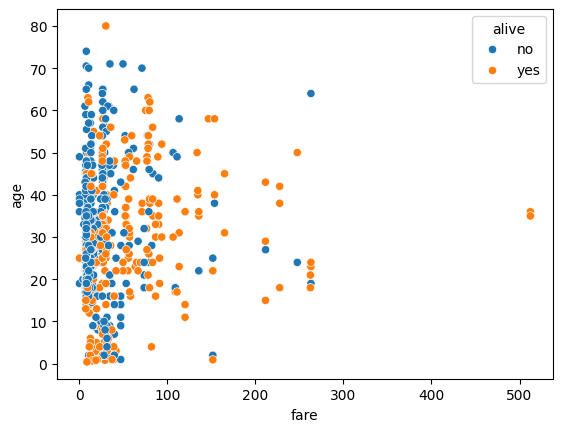

In [ ]:
sns.scatterplot(x=df["fare"], y=df["age"], hue = df['alive'] )

Azul (no) → pasajeros que no sobrevivieron.

Naranja (yes) → pasajeros que sí sobrevivieron.
Este scatter plot nos muestra:

Cada punto es un pasajero.

Su posición horizontal indica cuánto pagó.

Su posición vertical indica la edad.

El color indica si sobrevivió o no.

Con esto, podemos ver que el precio del pasaje (clase social) tuvo influencia en la probabilidad de sobrevivir, aunque no fue el único factor.



In [ ]:
df2.to_excel('ejemplo.xlsx', index=True)#indica que también se va a guardar la columna índice del DataFrame (la numeración de filas que aparece a la izquierda).

#Si pusieras index=False, no guardaría esa columna.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

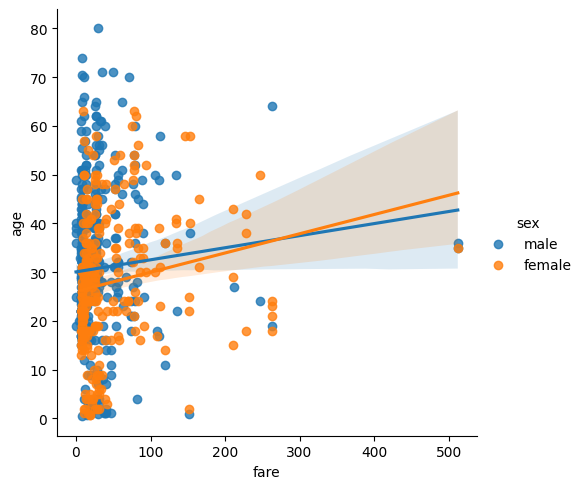

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.lmplot(data=df, x='fare', y='age', hue='sex')

Cada puntito representa un pasajero.
Ejemplo: un punto en (fare=50, age=30) significa que una persona de 30 años pagó una tarifa de 50.
Se ve una línea para hombres y otra para mujeres.

Ambas suben un poquito → quiere decir que a medida que la tarifa es más cara, los pasajeros tienden a ser un poco más grandes en edad.

No es una relación fuerte, pero hay una leve tendencia positiva.

Sombreado alrededor de las líneas:

Muestra la “incertidumbre” o intervalo de confianza.

Mientras más ancho, menos seguro es el modelo de la relación.

# Limpieza de Datos
## Eliminación y Sustitución de Valores Nulos
En primer lugar, verificaremos si existen valores nulos en el dataset:

In [ ]:
df.shape

(891, 15)

Nota:


*   NaN = Not a Number, se genera cuando intentamos escribir un valor no numerico en un campo numerico (ej: str en campo numerico)
*   Null = Valor Nulo o inexistente, se genera si no tenemos el valor correspondiente para ese campo en esa linea determinada o si el valor está corrupto.
*   Na = Null





In [ ]:
df.isna().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


In [ ]:
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


Podemos observar que existen valores nulos en las columnas 'age', 'deck' y 'embark_town'.

Podemos eliminar la columna 'deck' ya que contiene muchos valores nulos y no es relevante para nuestro análisis. Además, eliminaremos la columna 'embark_town' porque ya tenemos la información en la columna 'embarked'.

El codigo de abajo ordena la variable erdad para que los nulos aparezcan al final o al principio ....last si cambiamos no se ven al principio

In [ ]:
df2 = df.sort_values(by='age', ascending=False, na_position='first')
df2.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
17,1,2,male,NaN,0,0,13.0000,S,Second,man,True,NaN,Southampton,yes,True
19,1,3,female,NaN,0,0,7.2250,C,Third,woman,False,NaN,Cherbourg,yes,True
26,0,3,male,NaN,0,0,7.2250,C,Third,man,True,NaN,Cherbourg,no,True
28,1,3,female,NaN,0,0,7.8792,Q,Third,woman,False,NaN,Queenstown,yes,True


In [ ]:
df2 = df  #significa que cualquier cambio que hagamos en df2 también afectará a df, y viceversa, porque no es una copia independiente, sino dos nombres que apuntan al mismo objeto.

In [ ]:
#le decimos a pandas que queremos borrar columnas , axis=0 si queremos borrar filas, Aca eliminamos las columnas, pero no se guarda el cambio en df2.

#Esto es útil si solo quieres ver cómo se vería el DataFrame sin esas columnas sin modificarlo.

In [ ]:
df2.head(2)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False


In [ ]:
df2 = df2.drop(['deck', 'embark_town'], axis=1) #Eliminá estas columnas y guardá el resultado en df2. Aca creamos un nuevo DataFrame que es igual al original pero sin las columnas 'deck' y 'embark_town'.

#Luego lo reasignas a df2, por lo que df2 ahora sí tiene las columnas eliminadas.

#El DataFrame original se reemplaza por esta nueva versión. axis=1 le decimos que queremos eliminar una columna , si ponemos axis=0  se eliminan filas

In [ ]:
df2.drop(['deck', 'embark_town'], axis=1) #Mostrame cómo quedaría sin estas columnas.#Si hacemos print(df2) después, las columnas todavía estarán allí

In [ ]:
df2.tail()#sirve para ver las últimas filas de un DataFrame.

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,alive,alone
886,0,2,male,27.0,0,0,13.00,S,Second,man,True,no,True
887,1,1,female,19.0,0,0,30.00,S,First,woman,False,yes,True
888,0,3,female,NaN,1,2,23.45,S,Third,woman,False,no,False
889,1,1,male,26.0,0,0,30.00,C,First,man,True,yes,True
890,0,3,male,32.0,0,0,7.75,Q,Third,man,True,no,True


In [ ]:
#elimino la fila 851
df = df.drop(851)

como mostrar

In [ ]:
df2.tail()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,alive,alone
886,0,2,male,27.0,0,0,13.00,S,Second,man,True,no,True
887,1,1,female,19.0,0,0,30.00,S,First,woman,False,yes,True
888,0,3,female,NaN,1,2,23.45,S,Third,woman,False,no,False
889,1,1,male,26.0,0,0,30.00,C,First,man,True,yes,True
890,0,3,male,32.0,0,0,7.75,Q,Third,man,True,no,True


En cuanto a la columna 'age', podemos sustituir los valores nulos por la mediana de la columna:

In [ ]:
df2.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


In [ ]:
df2 = df2.sort_values(by='age', ascending=True, na_position='first')# Ordenamos el DataFrame df2 por la columna 'age' de menor a mayor.# Los valores faltantes (NaN) se ubican al principio gracias a 'na_position="first"'
df2.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,alive,alone
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,no,True
17,1,2,male,NaN,0,0,13.0000,S,Second,man,True,yes,True
19,1,3,female,NaN,0,0,7.2250,C,Third,woman,False,yes,True
26,0,3,male,NaN,0,0,7.2250,C,Third,man,True,no,True
28,1,3,female,NaN,0,0,7.8792,Q,Third,woman,False,yes,True


In [ ]:
df2['age'] = df2['age'].fillna(df2['age'].median())# Reemplazamos los valores faltantes (NaN) de la columna 'age'
# por la mediana de esa misma columna.
# Esto asegura que no queden datos vacíos y mantiene una representación realista
 # de la distribución de edades, ya que la mediana no se ve afectada por valores extremos

In [ ]:
df['age'].median()

28.0

In [ ]:
df2 = df  #asigna a df2 la misma referencia que df.#No crea una copia independiente, sino que ambos apuntan al mismo objeto en memoria.

#Esto significa que si modificás df2, también se modifica df, y viceversa.

In [ ]:
#Si querés crear una copia independiente que no afecte al original, deberías usar:
df2 = df.copy()

In [ ]:
df2.head(20)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,alive,alone
5,0,3,male,28.0,0,0,8.4583,Q,Third,man,True,no,True
17,1,2,male,28.0,0,0,13.0000,S,Second,man,True,yes,True
19,1,3,female,28.0,0,0,7.2250,C,Third,woman,False,yes,True
26,0,3,male,28.0,0,0,7.2250,C,Third,man,True,no,True
28,1,3,female,28.0,0,0,7.8792,Q,Third,woman,False,yes,True
29,0,3,male,28.0,0,0,7.8958,S,Third,man,True,no,True
31,1,1,female,28.0,1,0,146.5208,C,First,woman,False,yes,False
32,1,3,female,28.0,0,0,7.7500,Q,Third,woman,False,yes,True
36,1,3,male,28.0,0,0,7.2292,C,Third,man,True,yes,True
42,0,3,male,28.0,0,0,7.8958,C,Third,man,True,no,True


In [ ]:
df2['age'] = df2['age'].fillna(90)# Reemplaza los valores faltantes (NaN) de la columna 'age' con 90

In [ ]:
df2.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


In [ ]:
filtered_df = df2.loc[df2['embarked'].isnull()]  # se usa para localizar las filas que tienen un dato faltante en la columna embarked.
#df2.loc[...] → nos devuelve solamente las filas que cumplen esa condición.

In [ ]:
filtered_df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,alive,alone
61,1,1,female,38.0,0,0,80.0,NaN,First,woman,False,yes,True
829,1,1,female,62.0,0,0,80.0,NaN,First,woman,False,yes,True


## Eliminación de Duplicados
Luego, verificaremos si existen registros duplicados en el dataset:

In [ ]:
df.duplicated().sum() #df.duplicated() → revisa cada fila y marca si está repetida.
#True → la fila está duplicada.
#False → no está duplicada.
#.sum() → cuenta cuántos True hay.

np.int64(107)

In [ ]:
df['Duplicated'] = df.duplicated()#duplicated() detecta las filas repetidas y
#acá guardamos ese resultado en una nueva columna llamada Duplicated, para poder identificar cuáles son.

In [ ]:
df = df.sort_values(by='Duplicated', ascending=False)
df.head()  # Ordená el DataFrame poniendo primero las filas que están marcadas como duplicadas

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,Duplicated
466,0,2,male,NaN,0,0,0.00,S,Second,man,True,NaN,Southampton,no,True,True
526,1,2,female,50.0,0,0,10.50,S,Second,woman,False,NaN,Southampton,yes,True,True
196,0,3,male,NaN,0,0,7.75,Q,Third,man,True,NaN,Queenstown,no,True,True
790,0,3,male,NaN,0,0,7.75,Q,Third,man,True,NaN,Queenstown,no,True,True
198,1,3,female,NaN,0,0,7.75,Q,Third,woman,False,NaN,Queenstown,yes,True,True


Aca No estamos buscando personas exactamente iguales en TODO el dataset. Estamos buscando pasajeros que tienen iguales las características que consideran importantes: class y age.

In [ ]:
Relevant_columns = ['class','age']#columnas relevantes

In [ ]:
df['Duplicated_class'] = df.duplicated(Relevant_columns)# Compará las filas solamente teniendo en cuenta class y age y marcá como True las que se repiten

In [ ]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,Duplicated,Duplicated_class
656,0,3,male,NaN,0,0,7.8958,S,Third,man,True,NaN,Southampton,no,True,True,False
418,0,2,male,30.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True,True,False
87,0,3,male,NaN,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,True,True
300,1,3,female,NaN,0,0,7.7500,Q,Third,woman,False,NaN,Queenstown,yes,True,True,True
601,0,3,male,NaN,0,0,7.8958,S,Third,man,True,NaN,Southampton,no,True,True,True


la primer fila es la original duplicada true de la segunda que esta duplicada y todas asi menos la ultima que es false por que no se duplica

In [ ]:
df[df['Duplicated_class']==False].head()#Mostrame las primeras 5 filas que no fueron marcadas como duplicadas según class y age.

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,Duplicated,Duplicated_class
466,0,2,male,NaN,0,0,0.00,S,Second,man,True,NaN,Southampton,no,True,True,False
526,1,2,female,50.0,0,0,10.50,S,Second,woman,False,NaN,Southampton,yes,True,True,False
196,0,3,male,NaN,0,0,7.75,Q,Third,man,True,NaN,Queenstown,no,True,True,False
800,0,2,male,34.0,0,0,13.00,S,Second,man,True,NaN,Southampton,no,True,True,False
696,0,3,male,44.0,0,0,8.05,S,Third,man,True,NaN,Southampton,no,True,True,False


In [ ]:
df[df['Duplicated']==True].head(10)#Mostrame las primeras 10 filas que están marcadas como duplicadas.

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,Duplicated
466,0,2,male,NaN,0,0,0.0000,S,Second,man,True,NaN,Southampton,no,True,True
526,1,2,female,50.0,0,0,10.5000,S,Second,woman,False,NaN,Southampton,yes,True,True
196,0,3,male,NaN,0,0,7.7500,Q,Third,man,True,NaN,Queenstown,no,True,True
790,0,3,male,NaN,0,0,7.7500,Q,Third,man,True,NaN,Queenstown,no,True,True
198,1,3,female,NaN,0,0,7.7500,Q,Third,woman,False,NaN,Queenstown,yes,True,True
792,0,3,female,NaN,8,2,69.5500,S,Third,woman,False,NaN,Southampton,no,False,True
384,0,3,male,NaN,0,0,7.8958,S,Third,man,True,NaN,Southampton,no,True,True
101,0,3,male,NaN,0,0,7.8958,S,Third,man,True,NaN,Southampton,no,True,True
304,0,3,male,NaN,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,True
201,0,3,male,NaN,8,2,69.5500,S,Third,man,True,NaN,Southampton,no,False,True


In [ ]:
df.duplicated(subset=['embark_town']).sum()#contar los duplicados dentro de una columna en particular

887

Luego podríamos proceder a eliminar estos valores en caso de determinar que es necesario, para eso creamos una nueva versión del DataFrame sin los duplicados, sin modificar el df original.
Le decimos:Eliminá las filas duplicadas de df y guardá el resultado en df3. Entonces:

df → queda con los duplicados.
df3 → queda sin duplicados.

In [ ]:
df3 = df.drop_duplicates()
df3.duplicated().sum()

np.int64(0)

drop_duplicates()

Es un método de pandas que sirve para eliminar filas duplicadas en un DataFrame.

Por defecto, compara todas las columnas para decidir si una fila es igual a otra.

drop_duplicates() → elimina las filas duplicadas.

duplicated() → marca cuáles filas son duplicadas.

duplicated().sum() → cuenta cuántas filas duplicadas hay.

In [ ]:
df3[df3['Duplicated']==False].head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,Duplicated,Duplicated_class
645,1,1,male,48.0,1,0,76.7292,C,First,man,True,D,Cherbourg,yes,False,False,False
638,0,3,female,41.0,0,5,39.6875,S,Third,woman,False,NaN,Southampton,no,False,False,False
591,1,1,female,52.0,1,0,78.2667,C,First,woman,False,D,Cherbourg,yes,False,False,False
637,0,2,male,31.0,1,1,26.2500,S,Second,man,True,NaN,Southampton,no,False,False,False
590,0,3,male,35.0,0,0,7.1250,S,Third,man,True,NaN,Southampton,no,True,False,True


## Filtrado de Datos
Podemos filtrar los datos para obtener un subconjunto del dataset que cumpla con ciertas condiciones. Por ejemplo, podemos obtener un subconjunto con los pasajeros que sobrevivieron al desastre:

In [ ]:
df_survived = df[df['survived']==1] #Esto genera una serie booleana (True/False) indicando, para cada fila, si la columna "survived" vale 1. cuantos sobrevivientes

In [ ]:
df_survived.shape

(342, 17)

In [ ]:
df_female = df[df['sex']!='male']#Aquí estamos comparando la columna sex de df con el valor 'male'. contar cuantas mujeres hay

In [ ]:
df_female.shape

(314, 17)

## Unión de Datasets
Podemos unir datasets diferentes para agregar información adicional. Por ejemplo:

In [ ]:
# Crear dataset 1
data_1 = {'id': [1, 2, 3, 4],
          'nombre': ['Juan', 'Pedro', 'Ana', 'Marta'],
          'otro': ['6', '4', '3', '2']}
dataset_1 = pd.DataFrame(data_1)
dataset_1.head()

,id,nombre,otro
0,1,Juan,6
1,2,Pedro,4
2,3,Ana,3
3,4,Marta,2


In [ ]:
# Crear dataset 2
data_2 = {'id': [1, 2, 5, 2],
          'edad': [25, 35, 40, 30],
          'nombre': ['Juan', 'Pedro', 'Ana', 'Marta']}
dataset_2 = pd.DataFrame(data_2)
dataset_2.head()

,id,edad,nombre
0,1,25,Juan
1,2,35,Pedro
2,5,40,Ana
3,2,30,Marta


compara ambos y une las igualdades

In [ ]:
# Unir datasets
dataset = pd.merge(dataset_1, dataset_2, on=['id','nombre'], how='left')# merge nos permite unir dataset. on en base a que columnas clave queremos unir, how nos dice como se devuelve el resultado de la combinacion
dataset.head()

,id,nombre,otro,edad
0,1,Juan,6,25.0
1,2,Pedro,4,35.0
2,3,Ana,3,NaN
3,4,Marta,2,NaN


In [ ]:
dataset_concat = pd.concat([dataset_1,dataset_2], axis =0)

In [ ]:
dataset_concat.head(10)

,id,nombre,otro,edad
0,1,Juan,6,NaN
1,2,Pedro,4,NaN
2,3,Ana,3,NaN
3,4,Marta,2,NaN
0,1,Juan,NaN,25.0
1,2,Pedro,NaN,35.0
2,5,Ana,NaN,40.0
3,2,Marta,NaN,30.0


## Eliminación de Columnas Innecesarias
Podemos eliminar las columnas que no son relevantes para nuestro análisis. Por ejemplo, podemos eliminar las columnas 'class' y 'who':

In [ ]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,Duplicated,Duplicated_class
511,0,3,male,28.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,True,False
425,0,3,male,28.0,0,0,7.2500,S,Third,man,True,NaN,Southampton,no,True,True,True
223,0,3,male,28.0,0,0,7.8958,S,Third,man,True,NaN,Southampton,no,True,True,True
878,0,3,male,28.0,0,0,7.8958,S,Third,man,True,NaN,Southampton,no,True,True,True
877,0,3,male,19.0,0,0,7.8958,S,Third,man,True,NaN,Southampton,no,True,True,False


In [ ]:
df4 = df.drop(['class', 'who'], axis=1)
df4.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,adult_male,deck,embark_town,alive,alone,Duplicated
466,0,2,male,NaN,0,0,0.00,S,True,NaN,Southampton,no,True,True
526,1,2,female,50.0,0,0,10.50,S,False,NaN,Southampton,yes,True,True
196,0,3,male,NaN,0,0,7.75,Q,True,NaN,Queenstown,no,True,True
790,0,3,male,NaN,0,0,7.75,Q,True,NaN,Queenstown,no,True,True
198,1,3,female,NaN,0,0,7.75,Q,False,NaN,Queenstown,yes,True,True


## Conversión de Tipos de Datos
Podemos convertir los tipos de datos de las columnas según sea necesario. Por ejemplo, podemos convertir la columna 'sex' a valores numéricos:

In [ ]:
df5 = df4  #Tomá df4 y llamalo también df5
df5.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,adult_male,deck,embark_town,alive,alone,Duplicated
466,0,2,male,NaN,0,0,0.00,S,True,NaN,Southampton,no,True,True
526,1,2,female,50.0,0,0,10.50,S,False,NaN,Southampton,yes,True,True
196,0,3,male,NaN,0,0,7.75,Q,True,NaN,Queenstown,no,True,True
790,0,3,male,NaN,0,0,7.75,Q,True,NaN,Queenstown,no,True,True
198,1,3,female,NaN,0,0,7.75,Q,False,NaN,Queenstown,yes,True,True


In [ ]:
df5 = df #Ahora df5 pasa a apuntar a df, no a df4

In [ ]:
df5['sex'] = df5['sex'].map({'male': 0, 'female': 1})

In [ ]:
df5.info()

<class 'pandas.core.frame.DataFrame'>
Index: 890 entries, 466 to 890
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     890 non-null    int64   
 1   pclass       890 non-null    int64   
 2   sex          890 non-null    int64   
 3   age          713 non-null    float64 
 4   sibsp        890 non-null    int64   
 5   parch        890 non-null    int64   
 6   fare         890 non-null    float64 
 7   embarked     888 non-null    object  
 8   class        890 non-null    category
 9   who          890 non-null    object  
 10  adult_male   890 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  888 non-null    object  
 13  alive        890 non-null    object  
 14  alone        890 non-null    bool    
 15  Duplicated   890 non-null    bool    
dtypes: bool(3), category(2), float64(2), int64(5), object(4)
memory usage: 88.3+ KB


In [ ]:
df51 = df

In [ ]:
df51.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,Duplicated
466,0,2,0,NaN,0,0,0.00,S,Second,man,True,NaN,Southampton,no,True,True
526,1,2,1,50.0,0,0,10.50,S,Second,woman,False,NaN,Southampton,yes,True,True
196,0,3,0,NaN,0,0,7.75,Q,Third,man,True,NaN,Queenstown,no,True,True
790,0,3,0,NaN,0,0,7.75,Q,Third,man,True,NaN,Queenstown,no,True,True
198,1,3,1,NaN,0,0,7.75,Q,Third,woman,False,NaN,Queenstown,yes,True,True


In [ ]:
df51['sex'] = df51['sex'].astype('float64')#cambiar a float

In [ ]:
df51.info()

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 511 to 128
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   survived          891 non-null    int64   
 1   pclass            891 non-null    int64   
 2   sex               891 non-null    float64 
 3   age               891 non-null    float64 
 4   sibsp             891 non-null    int64   
 5   parch             891 non-null    int64   
 6   fare              891 non-null    float64 
 7   embarked          889 non-null    object  
 8   class             891 non-null    category
 9   who               891 non-null    object  
 10  adult_male        891 non-null    bool    
 11  deck              203 non-null    category
 12  embark_town       889 non-null    object  
 13  alive             891 non-null    object  
 14  alone             891 non-null    bool    
 15  Duplicated        891 non-null    bool    
 16  Duplicated_class  891 non-nul

In [ ]:
df51.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,Duplicated
466,0,2,0.0,NaN,0,0,0.00,S,Second,man,True,NaN,Southampton,no,True,True
526,1,2,1.0,50.0,0,0,10.50,S,Second,woman,False,NaN,Southampton,yes,True,True
196,0,3,0.0,NaN,0,0,7.75,Q,Third,man,True,NaN,Queenstown,no,True,True
790,0,3,0.0,NaN,0,0,7.75,Q,Third,man,True,NaN,Queenstown,no,True,True
198,1,3,1.0,NaN,0,0,7.75,Q,Third,woman,False,NaN,Queenstown,yes,True,True


### Normalización de Datos

Podemos normalizar(convertir) los datos para que tengan una misma escala

¿Para qué sirve?

Comparar variables en distintas escalas:

Ejemplo: si tenés “edad” (0–100) y “ingresos” (0–100000), los ingresos dominarían cualquier análisis.

Estandarizar pone todo en la misma escala.

Mejorar el rendimiento de algoritmos de Machine Learning:

Algunos modelos (KNN, regresión logística, SVM, redes neuronales) dependen de distancias o gradientes.

Si las variables no están en la misma escala, el modelo puede sesgarse.



In [ ]:
from sklearn.preprocessing import MinMaxScaler

df6 = df

### MinMaxScaler:

Es un metodo de normalizacion que utiliza los valores minimos y maximos de la dimension para normalizar la escala:

X_scaled = (X - X_min) / (X_max - X_min)

donde X es el valor original de la característica, X_max es el valor maximo de la característica y X_min es el valor minimo

COMO FUNCIONA?

Busca el valor mínimo y el máximo de la columna.

A cada valor le resta el mínimo.

Divide el resultado entre el rango (X_MAX-X_MIN)

Así, el mínimo se convierte en 0 y el máximo en 1.

Para qué sirve?

Muy útil en algoritmos basados en distancias (KNN, clustering).

Garantiza que todas las variables estén entre el mismo rango y ninguna domine por tener números más grandes.

A diferencia de la estandarización (que centra en 0 y escala con la desviación estándar), aquí los datos quedan “aplastados” en un rango definido.

In [ ]:
df6.head(10)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,Duplicated
466,0,2,0.0,NaN,0,0,0.0000,S,Second,man,True,NaN,Southampton,no,True,True
526,1,2,1.0,50.0,0,0,10.5000,S,Second,woman,False,NaN,Southampton,yes,True,True
196,0,3,0.0,NaN,0,0,7.7500,Q,Third,man,True,NaN,Queenstown,no,True,True
790,0,3,0.0,NaN,0,0,7.7500,Q,Third,man,True,NaN,Queenstown,no,True,True
198,1,3,1.0,NaN,0,0,7.7500,Q,Third,woman,False,NaN,Queenstown,yes,True,True
792,0,3,1.0,NaN,8,2,69.5500,S,Third,woman,False,NaN,Southampton,no,False,True
384,0,3,0.0,NaN,0,0,7.8958,S,Third,man,True,NaN,Southampton,no,True,True
101,0,3,0.0,NaN,0,0,7.8958,S,Third,man,True,NaN,Southampton,no,True,True
304,0,3,0.0,NaN,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,True
201,0,3,0.0,NaN,8,2,69.5500,S,Third,man,True,NaN,Southampton,no,False,True


In [ ]:
scaler = MinMaxScaler()
df6['age_normalized'] = scaler.fit_transform(df6[['age']])#guardamos dentro de una variable, age normalized nos normaliza todo entre 0 y 1

La normalización "aplastó" todas las edades a una escala común (0–1), manteniendo las proporciones relativas. Ahora, un modelo de machine learning puede trabajar mejor porque ninguna variable (como la edad en años) domina a otra con escalas muy distintas (ejemplo: fare puede llegar a cientos, mientras age rara vez supera 80).

**Normalización**

Lleva los valores generalmente a un rango entre 0 y 1.

Por ejemplo, si tenemos edades:

20   30   40   50   60

Después de normalizar podríamos tener:

0   0.25   0.50   0.75   1
** La idea: llevar los datos a un rango determinado, normalmente 0–1.**

In [ ]:
df6.head(10)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,Duplicated,Duplicated_class,age_normalized
511,0,3,0.0,28.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,True,False,0.346569
425,0,3,0.0,28.0,0,0,7.2500,S,Third,man,True,NaN,Southampton,no,True,True,True,0.346569
223,0,3,0.0,28.0,0,0,7.8958,S,Third,man,True,NaN,Southampton,no,True,True,True,0.346569
878,0,3,0.0,28.0,0,0,7.8958,S,Third,man,True,NaN,Southampton,no,True,True,True,0.346569
877,0,3,0.0,19.0,0,0,7.8958,S,Third,man,True,NaN,Southampton,no,True,True,False,0.233476
614,0,3,0.0,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,True,False,0.434531
613,0,3,0.0,28.0,0,0,7.7500,Q,Third,man,True,NaN,Queenstown,no,True,True,True,0.346569
418,0,2,0.0,30.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True,True,False,0.371701
612,1,3,1.0,28.0,1,0,15.5000,Q,Third,woman,False,NaN,Queenstown,yes,False,True,True,0.346569
420,0,3,0.0,28.0,0,0,7.8958,C,Third,man,True,NaN,Cherbourg,no,True,True,True,0.346569


### Estandarización (StandardScaler):
La estandarización es una técnica de normalización que escala los datos para que tengan una media de cero y una desviación estándar de uno. La fórmula para la estandarización es:

X_std = (X - mean(X)) / std(X)

donde X es el valor original de la característica, mean(X) es la media de la característica, y std(X) es la desviación estándar de la característica.

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df6['age_standardized'] = scaler.fit_transform(df6[['age']])

fit() → calcula la media y la desviación estándar de la columna age.

transform() → aplica la fórmula de estandarización a cada valor de age.

fit_transform() → hace ambos pasos juntos.

El resultado se guarda en una nueva columna age_standardized.

**Estandarización**

Transforma los datos para que tengan:

media = 0
desvío estándar = 1

Por ejemplo:

Edad → 20  30  40  50  60

podría transformarse aproximadamente en:

-1.41  -0.71   0   0.71   1.41

 **Acá no buscamos que estén entre 0 y 1. Los valores pueden ser negativos o mayores que 1**.

Las dos técnicas sirven para poner las variables en escalas comparables. La normalización lleva los valores a un rango, generalmente de 0 a 1. La estandarización los transforma tomando como referencia la media y el desvío estándar, dejando la media en 0 y el desvío en 1

In [ ]:
df6.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,Duplicated,age_normalized,age_standardized
466,0,2,0.0,NaN,0,0,0.00,S,Second,man,True,NaN,Southampton,no,True,True,NaN,NaN
526,1,2,1.0,50.0,0,0,10.50,S,Second,woman,False,NaN,Southampton,yes,True,True,0.623021,1.41103
196,0,3,0.0,NaN,0,0,7.75,Q,Third,man,True,NaN,Queenstown,no,True,True,NaN,NaN
790,0,3,0.0,NaN,0,0,7.75,Q,Third,man,True,NaN,Queenstown,no,True,True,NaN,NaN
198,1,3,1.0,NaN,0,0,7.75,Q,Third,woman,False,NaN,Queenstown,yes,True,True,NaN,NaN


Ahora en age_standardized, los valores tienen:

Media ≈ 0

Desviación estándar = 1

Por eso ves números negativos (valores menores a la media) y positivos (valores mayores a la media).

Ejemplo de interpretación:

Si age_standardized = -0.10 → la edad está ligeramente por debajo del promedio.

Si age_standardized = -0.79 → la edad está casi una desviación estándar por debajo del promedio.

Si age_standardized = 2.0 → esa persona tiene una edad 2 desviaciones estándar por encima del promedio → un valor muy alto comparado al resto.


## Eliminación de Outliers

Un outlier (o valor atípico) es un dato que se aleja significativamente del resto de los valores en un conjunto de datos.
Es decir, no sigue el mismo patrón que la mayoría de las observaciones y aparece como un valor “extremo” o inusual.
es un valor que no parece encajar con el comportamiento general de los datos.

Ejemplo:

Si en una clase los alumnos tienen estas edades:

15, 16, 16, 15, 17, 16, 42


El valor 42 sería un outlier, porque está muy lejos del resto (la mayoría está entre 15 y 17).

Importancia de detectarlos:

Pueden indicar errores en la recolección de datos (ej: alguien tipeó mal un número).

O bien ser valores reales pero excepcionales, que nos dan información interesante (ej: un paciente con un valor clínico fuera de lo normal).

A veces conviene eliminarlos (si son errores), y otras analizarlos aparte (si son casos especiales).

Podemos eliminar los outliers para reducir el impacto que tienen en nuestros análisis. Por ejemplo, podemos eliminar los registros que tengan un valor de tarifa mayor a 500:

In [ ]:
df.shape

(891, 19)

In [ ]:
df7 = df[df['fare']<=500]#Quiero quedarme solamente con los pasajeros cuyo fare (tarifa) sea menor o igual a 500.
df7.shape

(888, 19)

## Creación de Nuevas Variables
Podemos crear nuevas variables a partir de las variables existentes. Por ejemplo, podemos crear una variable 'family_size' que represente el tamaño de la familia:La columna family_size se crea porque a veces tener familia a bordo puede influir en la supervivencia
df['sibsp'] → es la cantidad de hermanos/esposos que viajan con la persona en el Titanic.

df['parch'] → es la cantidad de padres/hijos que viajan con esa persona.

+ 1 → se suma la persona misma.

Esta fórmula calcula el tamaño de la familia a bordo, sumando hermanos/esposos + padres/hijos + el pasajero.

El resultado se guarda en una nueva columna llamada family_size dentro del DataFrame df.

In [ ]:
df['family_size'] = df['sibsp'] + df['parch'] + 1
df.head(20)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,Duplicated,Duplicated_class,family_size
466,0,2,male,NaN,0,0,0.0000,S,Second,man,True,NaN,Southampton,no,True,True,False,1
526,1,2,female,50.0,0,0,10.5000,S,Second,woman,False,NaN,Southampton,yes,True,True,False,1
196,0,3,male,NaN,0,0,7.7500,Q,Third,man,True,NaN,Queenstown,no,True,True,False,1
790,0,3,male,NaN,0,0,7.7500,Q,Third,man,True,NaN,Queenstown,no,True,True,True,1
198,1,3,female,NaN,0,0,7.7500,Q,Third,woman,False,NaN,Queenstown,yes,True,True,True,1
792,0,3,female,NaN,8,2,69.5500,S,Third,woman,False,NaN,Southampton,no,False,True,True,11
384,0,3,male,NaN,0,0,7.8958,S,Third,man,True,NaN,Southampton,no,True,True,True,1
101,0,3,male,NaN,0,0,7.8958,S,Third,man,True,NaN,Southampton,no,True,True,True,1
304,0,3,male,NaN,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,True,True,1
201,0,3,male,NaN,8,2,69.5500,S,Third,man,True,NaN,Southampton,no,False,True,True,11
